## (a) Discover the latent factor structure (2 marks)

In [2]:
!pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


#### Load the data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

ticks_mon= pd.read_csv("../Data/ticks_mon.csv")
ticks_mon.head(5)



,timestamp,asset_id,mid_return
0,2026-06-01 09:00:00+00:00,S01,0.000744
1,2026-06-01 09:00:00+00:00,S02,0.000096
2,2026-06-01 09:00:00+00:00,S03,0.000517
3,2026-06-01 09:00:00+00:00,S04,0.000685
4,2026-06-01 09:00:00+00:00,S05,0.000158


In [6]:
print(ticks_mon.shape)
print(ticks_mon.columns)

(360000, 3)
Index(['timestamp', 'asset_id', 'mid_return'], dtype='str')


#### Pivot the data

In [8]:
returns_mon = ticks_mon.pivot(
    index="timestamp",
    columns="asset_id",
    values="mid_return"
)

returns_mon = returns_mon.dropna()
print(returns_mon.shape)
returns_mon.head()

(28245, 12)


asset_id,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12
timestamp,,,,,,,,,,,,
2026-06-01 09:00:00+00:00,0.000744,0.000096,0.000517,0.000685,0.000158,-0.000118,-0.000781,-0.000730,-0.000489,0.000061,0.000537,0.000428
2026-06-01 09:00:00.840000+00:00,-0.000591,-0.001197,-0.001481,-0.000599,-0.000557,-0.000576,-0.001134,0.000212,0.000255,0.001765,0.001937,0.001463
2026-06-01 09:00:01.680000+00:00,-0.001641,-0.002073,-0.001942,-0.000795,-0.000048,0.000347,0.001576,0.001984,0.001770,0.000640,0.000353,-0.001289
2026-06-01 09:00:02.520000+00:00,-0.000704,-0.000288,-0.000453,-0.000004,-0.000044,0.000009,0.000674,0.000408,-0.000095,-0.000044,-0.000185,0.000014
2026-06-01 09:00:03.360000+00:00,0.000853,0.000956,0.000549,-0.000029,-0.000602,-0.001143,0.000047,-0.000572,0.000565,-0.000677,0.000504,0.000236


#### Fit on centered return

In [9]:
pca_mon = PCA()

pca_mon.fit(returns_mon.values)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [10]:
eigenvalues = pca_mon.explained_variance_

print(eigenvalues)

[6.09324458e-06 3.00449354e-06 1.06626773e-06 9.27543550e-08
 9.22429744e-08 9.14981563e-08 9.01808586e-08 8.98359347e-08
 8.91540137e-08 8.86322290e-08 8.82667631e-08 8.78036987e-08]


#### Spree plot

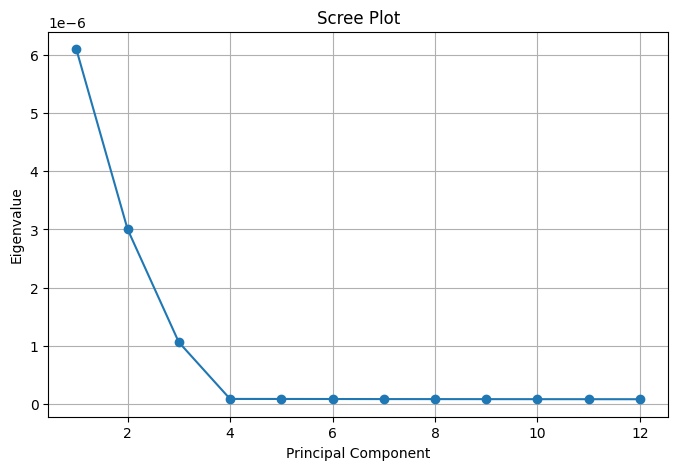

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)

plt.show()

In [12]:
explained_ratio = pca_mon.explained_variance_ratio_

for i, ratio in enumerate(explained_ratio, start=1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

PC1: 0.5552 (55.52%)
PC2: 0.2738 (27.38%)
PC3: 0.0972 (9.72%)
PC4: 0.0085 (0.85%)
PC5: 0.0084 (0.84%)
PC6: 0.0083 (0.83%)
PC7: 0.0082 (0.82%)
PC8: 0.0082 (0.82%)
PC9: 0.0081 (0.81%)
PC10: 0.0081 (0.81%)
PC11: 0.0080 (0.80%)
PC12: 0.0080 (0.80%)


#### Kaiser criterion

In [13]:
mean_eigenvalue = np.mean(eigenvalues)

print("Mean eigenvalue:", mean_eigenvalue)

kaiser_k = np.sum(eigenvalues > mean_eigenvalue)

print("Kaiser K =", kaiser_k)

Mean eigenvalue: 9.145312362624922e-07
Kaiser K = 3


#### Broken-stick criterion

In [17]:
p = len(eigenvalues)  # should be 12

broken_stick_thresholds = []

for j in range(1, p + 1):
    threshold = mean_eigenvalue * sum(1/i for i in range(j, p+1))
    broken_stick_thresholds.append(threshold)

broken_stick_thresholds = np.array(broken_stick_thresholds)

print(broken_stick_thresholds)



[2.83798310e-06 1.92345186e-06 1.46618624e-06 1.16134250e-06
 9.32709689e-07 7.49803442e-07 5.97381569e-07 4.66734250e-07
 3.52417845e-07 2.50803263e-07 1.59350140e-07 7.62109364e-08]


PC1: eigenvalue=6.093e-06, threshold=2.838e-06, keep=True
PC2: eigenvalue=3.004e-06, threshold=1.923e-06, keep=True
PC3: eigenvalue=1.066e-06, threshold=1.466e-06, keep=False
PC4: eigenvalue=9.275e-08, threshold=1.161e-06, keep=False
PC5: eigenvalue=9.224e-08, threshold=9.327e-07, keep=False
PC6: eigenvalue=9.150e-08, threshold=7.498e-07, keep=False
PC7: eigenvalue=9.018e-08, threshold=5.974e-07, keep=False
PC8: eigenvalue=8.984e-08, threshold=4.667e-07, keep=False
PC9: eigenvalue=8.915e-08, threshold=3.524e-07, keep=False
PC10: eigenvalue=8.863e-08, threshold=2.508e-07, keep=False
PC11: eigenvalue=8.827e-08, threshold=1.594e-07, keep=False
PC12: eigenvalue=8.780e-08, threshold=7.621e-08, keep=True
Broken-Stick K = 2


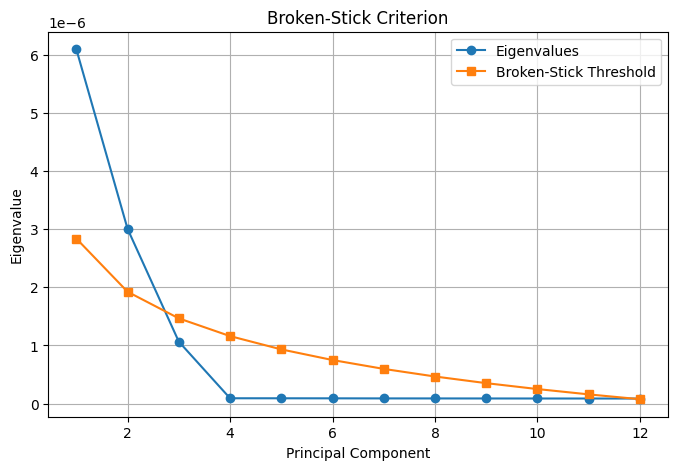

In [18]:
for j in range(p):
    print(
        f"PC{j+1}: "
        f"eigenvalue={eigenvalues[j]:.3e}, "
        f"threshold={broken_stick_thresholds[j]:.3e}, "
        f"keep={eigenvalues[j] > broken_stick_thresholds[j]}"
    )


broken_stick_k = 0

for i in range(len(eigenvalues)):
    if eigenvalues[i] > broken_stick_thresholds[i]:
        broken_stick_k += 1
    else:
        break

print("Broken-Stick K =", broken_stick_k)



plt.figure(figsize=(8,5))

plt.plot(range(1,p+1), eigenvalues,
         marker='o', label='Eigenvalues')

plt.plot(range(1,p+1), broken_stick_thresholds,
         marker='s', label='Broken-Stick Threshold')

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Broken-Stick Criterion")
plt.legend()
plt.grid(True)

plt.show()

#### Parallel Analysis

In [19]:
X = returns_mon.values
X_centered = X - X.mean(axis=0)

n_resamples = 500

p = X_centered.shape[1]  # 12 assets

random_eigs = np.zeros((n_resamples, p))

for r in range(n_resamples):

    X_shuffled = np.empty_like(X_centered)

    for j in range(p):
        X_shuffled[:, j] = np.random.permutation(
            X_centered[:, j]
        )

    pca_rand = PCA()
    pca_rand.fit(X_shuffled)

    random_eigs[r] = pca_rand.explained_variance_

parallel_thresholds = np.percentile(
    random_eigs,
    95,
    axis=0
)


PC1: real=6.093e-06, threshold=1.194e-06, keep=True
PC2: real=3.004e-06, threshold=1.173e-06, keep=True
PC3: real=1.066e-06, threshold=1.063e-06, keep=True
PC4: real=9.275e-08, threshold=1.051e-06, keep=False
PC5: real=9.224e-08, threshold=1.042e-06, keep=False
PC6: real=9.150e-08, threshold=1.034e-06, keep=False
PC7: real=9.018e-08, threshold=8.027e-07, keep=False
PC8: real=8.984e-08, threshold=7.931e-07, keep=False
PC9: real=8.915e-08, threshold=7.859e-07, keep=False
PC10: real=8.863e-08, threshold=7.798e-07, keep=False
PC11: real=8.827e-08, threshold=6.620e-07, keep=False
PC12: real=8.780e-08, threshold=6.513e-07, keep=False
Parallel Analysis K = 3


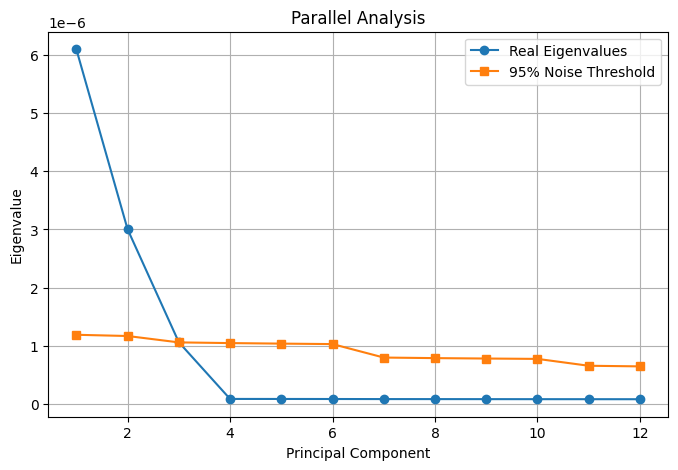

In [20]:
for i in range(p):

    print(
        f"PC{i+1}: "
        f"real={eigenvalues[i]:.3e}, "
        f"threshold={parallel_thresholds[i]:.3e}, "
        f"keep={eigenvalues[i] > parallel_thresholds[i]}"
    )

parallel_k = 0

for i in range(p):
    if eigenvalues[i] > parallel_thresholds[i]:
        parallel_k += 1
    else:
        break

print("Parallel Analysis K =", parallel_k)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,p+1),
    eigenvalues,
    marker='o',
    label='Real Eigenvalues'
)

plt.plot(
    range(1,p+1),
    parallel_thresholds,
    marker='s',
    label='95% Noise Threshold'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
results = pd.DataFrame({
    "PC": range(1,13),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_ratio,
    "Cumulative Variance": np.cumsum(explained_ratio)
})

results

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,1,6.093245e-06,0.555225,0.555225
1,2,3.004494e-06,0.273774,0.828998
2,3,1.066268e-06,0.097160,0.926158
3,4,9.275436e-08,0.008452,0.934610
4,5,9.224297e-08,0.008405,0.943015
5,6,9.149816e-08,0.008337,0.951353
6,7,9.018086e-08,0.008217,0.959570
7,8,8.983593e-08,0.008186,0.967756
8,9,8.915401e-08,0.008124,0.975880
9,10,8.863223e-08,0.008076,0.983956


### Selection of Number of Principal Components (K)

The scree plot shows a clear elbow at the third principal component. The Kaiser criterion retains 3 components, while Horn's parallel analysis also identifies 3 significant components. The broken-stick criterion is more conservative and suggests retaining 2 components. Since the majority of criteria support three components and the first three components explain most of the variance, we adopt **K = 3** for all subsequent analyses.

## (b) Interpret the structure (2 marks)

In [22]:
loadings = pd.DataFrame(
    pca_mon.components_[:3].T,
    index=returns_mon.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings

,PC1,PC2,PC3
asset_id,,,
S01,0.410599,-0.003313,0.287835
S02,0.353446,0.203097,0.289523
S03,0.205406,0.354235,0.288480
S04,0.001509,0.408604,-0.290105
S05,-0.203043,0.354685,-0.285454
S06,-0.352471,0.206035,-0.289170
S07,-0.407461,0.001603,0.291184
S08,-0.354224,-0.204062,0.288192
S09,-0.204659,-0.353641,0.286390


In [23]:
print("PC1")
print(loadings["PC1"].sort_values())

print("\nPC2")
print(loadings["PC2"].sort_values())

print("\nPC3")
print(loadings["PC3"].sort_values())

PC1
asset_id
S07   -0.407461
S08   -0.354224
S06   -0.352471
S09   -0.204659
S05   -0.203043
S10   -0.001205
S04    0.001509
S11    0.203045
S03    0.205406
S12    0.352441
S02    0.353446
S01    0.410599
Name: PC1, dtype: float64

PC2
asset_id
S10   -0.405833
S11   -0.353673
S09   -0.353641
S08   -0.204062
S12   -0.203858
S01   -0.003313
S07    0.001603
S02    0.203097
S06    0.206035
S03    0.354235
S05    0.354685
S04    0.408604
Name: PC2, dtype: float64

PC3
asset_id
S10   -0.290161
S04   -0.290105
S11   -0.290034
S06   -0.289170
S12   -0.287520
S05   -0.285454
S09    0.286390
S01    0.287835
S08    0.288192
S03    0.288480
S02    0.289523
S07    0.291184
Name: PC3, dtype: float64


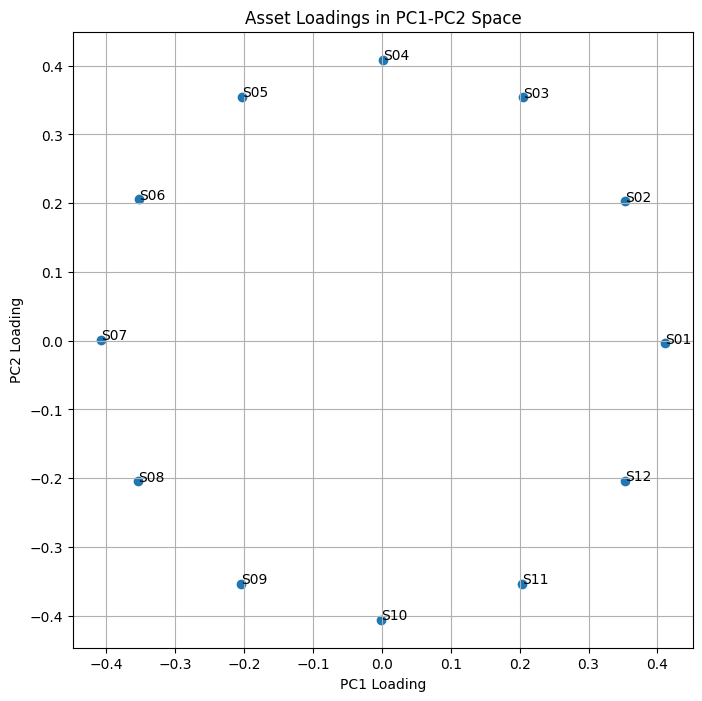

In [24]:
plt.figure(figsize=(8,8))

plt.scatter(loadings["PC1"], loadings["PC2"])

for asset in loadings.index:
    plt.annotate(
        asset,
        (loadings.loc[asset,"PC1"],
         loadings.loc[asset,"PC2"])
    )

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Asset Loadings in PC1-PC2 Space")
plt.grid(True)

plt.show()

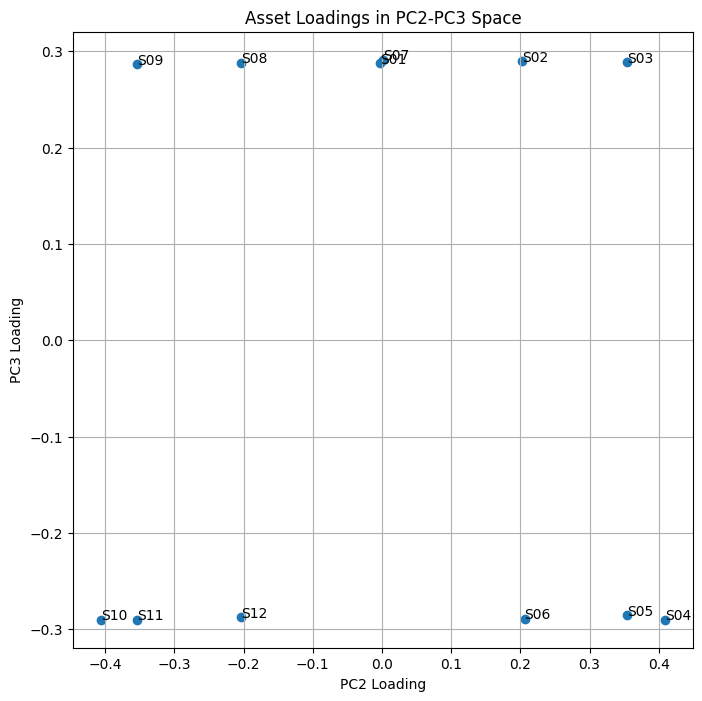

In [25]:
plt.figure(figsize=(8,8))

plt.scatter(loadings["PC2"], loadings["PC3"])

for asset in loadings.index:
    plt.annotate(
        asset,
        (loadings.loc[asset,"PC2"],
         loadings.loc[asset,"PC3"])
    )

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("Asset Loadings in PC2-PC3 Space")
plt.grid(True)

plt.show()

### Interpretation of the Factor Structure

The loading cloud in the (PC1, PC2) plane forms an approximately regular 12-sided polygon, with the assets distributed nearly uniformly around the origin. The points are not clustered and exhibit strong rotational symmetry, suggesting a highly structured latent factor model.

PC1 and PC2 represent the two dominant orthogonal directions of variation. The loadings vary smoothly around the polygon and encode broad co-movement patterns rather than asset-specific effects. Together, PC1 and PC2 explain approximately 82.9% of the total variance.

PC3 separates the assets into two groups with approximately equal-magnitude positive and negative loadings, indicating a weaker secondary contrast factor.

Since PCA eigenvectors are only defined up to sign, reflections of the loading cloud do not alter the underlying geometric interpretation.

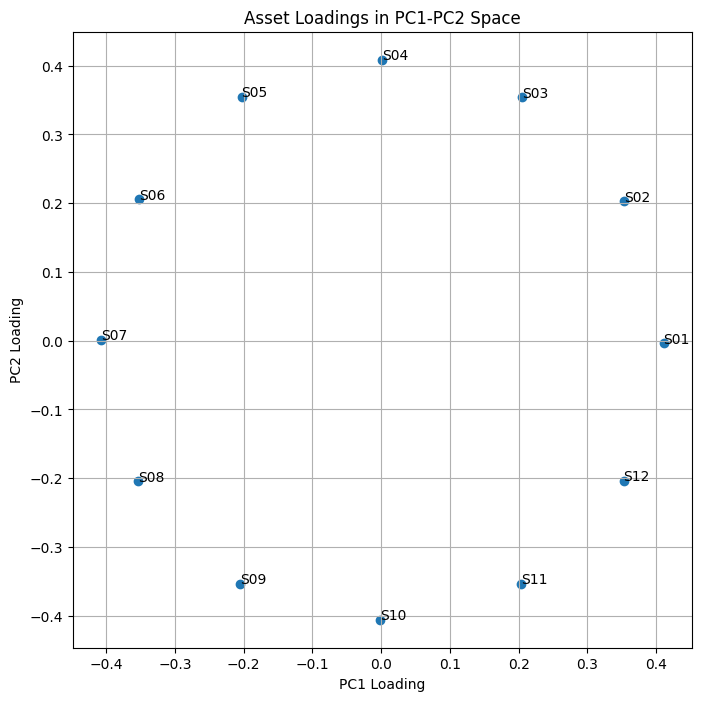

In [26]:
plt.figure(figsize=(8,8))
plt.scatter(loadings["PC1"], loadings["PC2"])

for asset in loadings.index:
    plt.annotate(asset,
                 (loadings.loc[asset,"PC1"],
                  loadings.loc[asset,"PC2"]))

plt.gca().set_aspect('equal')
plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Asset Loadings in PC1-PC2 Space")
plt.grid(True)
plt.show()

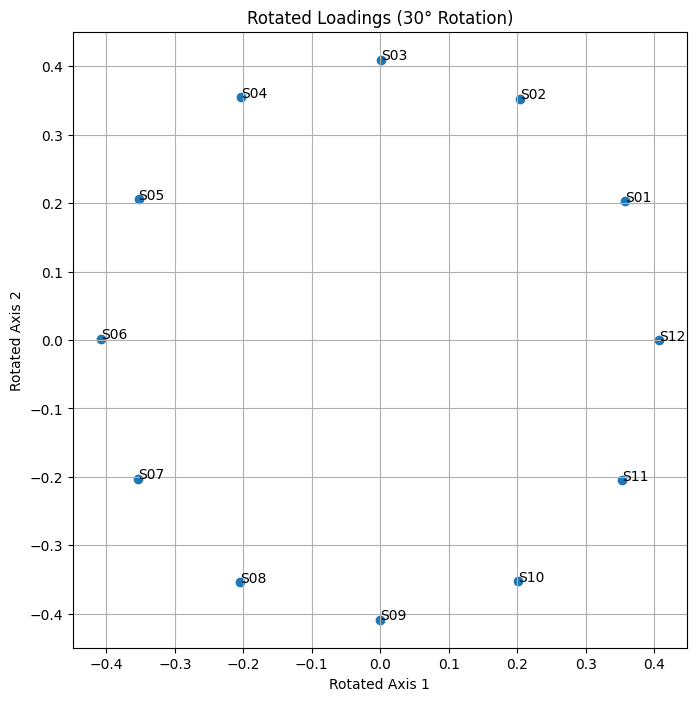

In [27]:
import numpy as np

theta = np.deg2rad(30)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

L = loadings[["PC1", "PC2"]].values

L_rot = L @ R.T

rot_loadings = pd.DataFrame(
    L_rot,
    index=loadings.index,
    columns=["Rot1", "Rot2"]
)

rot_loadings

plt.figure(figsize=(8,8))

plt.scatter(
    rot_loadings["Rot1"],
    rot_loadings["Rot2"]
)

for asset in rot_loadings.index:
    plt.annotate(
        asset,
        (
            rot_loadings.loc[asset,"Rot1"],
            rot_loadings.loc[asset,"Rot2"]
        )
    )

plt.gca().set_aspect('equal')

plt.xlabel("Rotated Axis 1")
plt.ylabel("Rotated Axis 2")
plt.title("Rotated Loadings (30° Rotation)")
plt.grid(True)

plt.show()

In [28]:
X = returns_mon.values

X_centered = X - X.mean(axis=0)

V = pca_mon.components_[:2].T
V_rot = V @ R.T
scores_rot = X_centered @ V_rot
print(scores_rot.shape)

rot_var1 = np.var(scores_rot[:,0], ddof=1)
rot_var2 = np.var(scores_rot[:,1], ddof=1)

print("Rotated variance 1 =", rot_var1)
print("Rotated variance 2 =", rot_var2)

print("Rotated total variance =",
      rot_var1 + rot_var2)

lambda1 = eigenvalues[0]
lambda2 = eigenvalues[1]

print("λ1 =", lambda1)
print("λ2 =", lambda2)

print("λ1 + λ2 =", lambda1 + lambda2)

(28245, 2)
Rotated variance 1 = 5.321056821592879e-06
Rotated variance 2 = 3.776681301358028e-06
Rotated total variance = 9.097738122950906e-06
λ1 = 6.0932445817103026e-06
λ2 = 3.004493541240606e-06
λ1 + λ2 = 9.097738122950908e-06


### Rotation Ambiguity

The first two principal components were rotated by 30° and the asset loadings were re-plotted. The geometric arrangement of the assets remained unchanged apart from a rigid rotation of the coordinate system; the approximately regular dodecagon structure was preserved.

Before rotation, the variances explained by the first two components were λ₁ = 6.093×10⁻⁶ and λ₂ = 3.004×10⁻⁶. After rotation, the variances along the rotated axes became 5.321×10⁻⁶ and 3.777×10⁻⁶. Although the variance allocation across the individual axes changed, the total explained variance remained unchanged:

λ₁ + λ₂ = 9.098×10⁻⁶

Rotated variance 1 + Rotated variance 2 = 9.098×10⁻⁶

This demonstrates the rotation ambiguity of unsupervised factor models. Individual PCA factors are not uniquely defined, since any orthogonal rotation of the retained factor space produces an equivalent representation. The meaningful object is therefore the two-dimensional factor subspace spanned by the retained components rather than the individual principal components themselves.